# Walkthrough of `tests/test_pipeline.py`

This notebook reproduces the end-to-end checks from the test file step by step, with plots at each stage so you can visualize what each part of the pipeline is doing.

1. `Q_000(s)` from pair counts vs the analytic self-overlap volume of a sphere.
2. The monopole covariance vs a brute-force evaluation for an isotropic `P(k)`.
3. A far-away sphere (distant observer): ratios `C_{l1 l2}/C_00` close to the periodic-box values.

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, eval_legendre

from pkcov import Tracer, PowerSpectrumModel, GaussianCovariance
from pkcov.tracers import Window
from pkcov.windows import TripolarWindow
from pkcov.wigner import FOUR_PI

## Helper functions

Same helpers used by the tests: synthetic randoms in a sphere, a smooth isotropic `P(k)` model, a brute-force monopole covariance, and a 4-Legendre integral used for the box-multipole ratios.

In [2]:
def sphere_randoms(R, n, center=(0.0, 0.0, 0.0), nbar=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    pts = []
    while sum(len(p) for p in pts) < n:
        x = rng.uniform(-R, R, size=(2 * n, 3))
        pts.append(x[np.sum(x * x, axis=1) < R * R])
    pos = np.concatenate(pts)[:n] + np.asarray(center)
    V = 4 * np.pi / 3 * R ** 3
    alpha = nbar * V / n
    return {'POSITION': pos, 'WEIGHT': np.ones(n), 'NZ': np.full(n, nbar)}, alpha


def pk_model():
    k = np.geomspace(1e-3, 1.0, 400)
    P0 = 2e4 * (k / 0.05) / (1 + (k / 0.05) ** 2.2)     # smooth, isotropic
    return k, P0


def bruteforce_monopole(R, k_edges, kfun, nq=24):
    """2/I^2 * <P P |W~(k1-k2)|^2> over shells, for a top-hat sphere of radius R."""
    I = 4 * np.pi / 3 * R ** 3                                # per nbar^2 (nbar cancels)
    q = np.linspace(1e-6, 2 * k_edges[-1] + 0.05, 200001)
    wt = 4 * np.pi * R ** 3 * spherical_jn(1, q * R) / (q * R)
    cum = np.concatenate([[0.0], np.cumsum(0.5 * (q[1:] * wt[1:] ** 2 + q[:-1] * wt[:-1] ** 2) * np.diff(q))])
    G = lambda x: np.interp(x, q, cum)
    x, wgl = np.polynomial.legendre.leggauss(nq)
    nb = len(k_edges) - 1
    C = np.zeros((nb, nb))
    for i in range(nb):
        k1 = 0.5 * (k_edges[i + 1] - k_edges[i]) * x + 0.5 * (k_edges[i + 1] + k_edges[i])
        w1 = 0.5 * (k_edges[i + 1] - k_edges[i]) * wgl * k1 ** 2 * kfun(k1)
        n1 = (k_edges[i + 1] ** 3 - k_edges[i] ** 3) / 3
        for j in range(nb):
            k2 = 0.5 * (k_edges[j + 1] - k_edges[j]) * x + 0.5 * (k_edges[j + 1] + k_edges[j])
            w2 = 0.5 * (k_edges[j + 1] - k_edges[j]) * wgl * k2 ** 2 * kfun(k2)
            n2 = (k_edges[j + 1] ** 3 - k_edges[j] ** 3) / 3
            K1, K2 = k1[:, None], k2[None, :]
            F = (G(K1 + K2) - G(np.abs(K1 - K2))) / (2 * K1 * K2)      # int dmu/2 |W~|^2
            C[i, j] = 2.0 / I ** 2 * np.sum(w1[:, None] * w2[None, :] * F) / (n1 * n2)
    return C


def _legendre4(l1, l2, L1, L2):
    x, w = np.polynomial.legendre.leggauss(40)
    return 0.5 * np.sum(w * eval_legendre(l1, x) * eval_legendre(l2, x) * eval_legendre(L1, x) * eval_legendre(L2, x))

## Test 1 — `Q_000(s)` for a sphere of randoms

### Step 1: build the randoms and the tracer/window

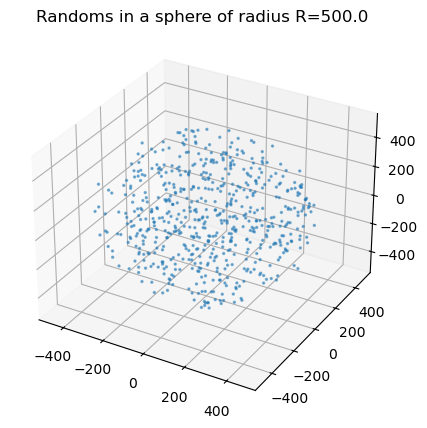

In [3]:
R, n, nbar = 500.0, 12000, 2e-4
rnd, alpha = sphere_randoms(R, n, nbar=nbar)
tr = Tracer('T', rnd, alpha)
w = Window('W', tr, tr)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': '3d'})
sub = rnd['POSITION'][::20]
ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=2, alpha=0.5)
ax.set_title(f'Randoms in a sphere of radius R={R}')
plt.show()

### Step 2: compute the tripolar window (pair counts) and compare `Q_000` to the analytic self-overlap volume

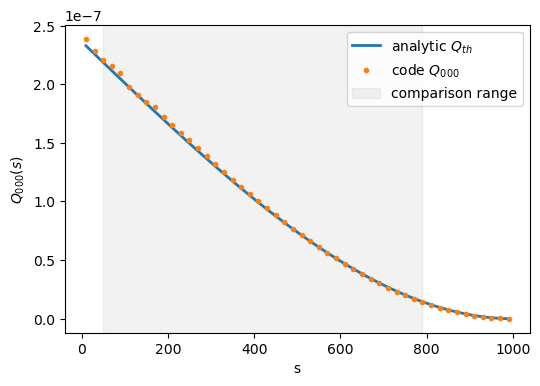

max rel. diff in comparison range: 0.028529257575583444


In [4]:
s_edges = np.arange(0, 2 * R + 20, 20.0)
tw = TripolarWindow(w, w, [(0, 0, 0), (0, 0, 2)], s_edges, n_sub=3000).compute()
s = tw.s_centers
Vov = np.pi / 12 * (4 * R + s) * (2 * R - s) ** 2
Q_th = FOUR_PI ** (-1.5) * FOUR_PI * nbar ** 4 * Vov
sel = (s > 40) & (s < 1.6 * R)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, Q_th, label='analytic $Q_{th}$', lw=2)
ax.plot(s, tw.Q[(0, 0, 0)], 'o', ms=3, label='code $Q_{000}$')
ax.axvspan(s[sel][0], s[sel][-1], color='gray', alpha=0.1, label='comparison range')
ax.set_xlabel('s')
ax.set_ylabel('$Q_{000}(s)$')
ax.legend()
plt.show()

print('max rel. diff in comparison range:', np.max(np.abs(tw.Q[(0, 0, 0)][sel] / Q_th[sel] - 1)))

### Step 3: check isotropy — the `(0,0,2)` s-quadrupole of an origin-centred sphere should vanish

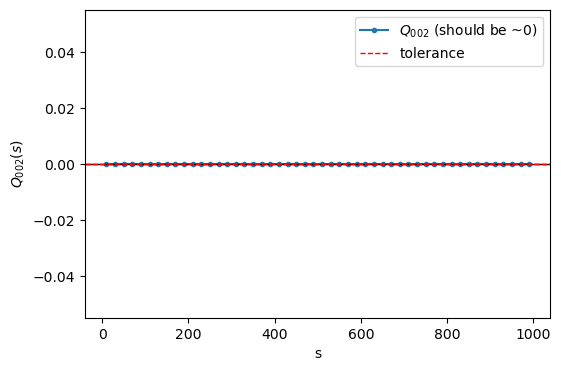

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(s, tw.Q[(0, 0, 2)], 'o-', ms=3, label='$Q_{002}$ (should be ~0)')
ax.axhline(0, color='k', lw=1)
ax.axhline(0.03 * np.max(np.abs(Q_th[sel])), color='r', ls='--', lw=1, label='tolerance')
ax.axhline(-0.03 * np.max(np.abs(Q_th[sel])), color='r', ls='--', lw=1)
ax.set_xlabel('s')
ax.set_ylabel('$Q_{002}(s)$')
ax.legend()
plt.show()

## Test 2 — monopole covariance vs brute force

### Step 1: set up the tracer, the power spectrum model, and the k-bins

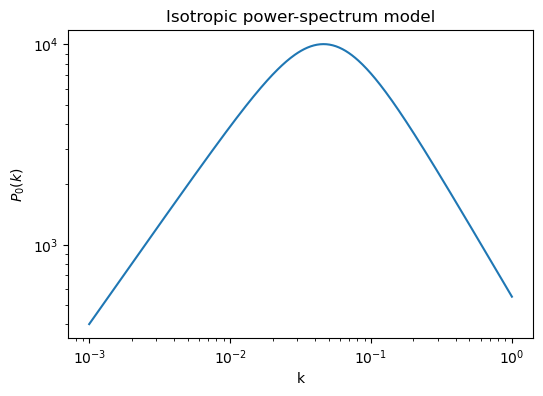

k_edges: [0.02 0.04 0.06 0.08 0.1  0.12]


In [6]:
R, n, nbar = 500.0, 12000, 2e-4
rnd, alpha = sphere_randoms(R, n, nbar=nbar)
tr = Tracer('T', rnd, alpha)
k, P0 = pk_model()

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(k, P0)
ax.set_xlabel('k')
ax.set_ylabel('$P_0(k)$')
ax.set_title('Isotropic power-spectrum model')
plt.show()

model = PowerSpectrumModel()
model.add(('T', 'T'), {0: (k, P0)})
k_edges = np.arange(0.02, 0.13, 0.02)
print('k_edges:', k_edges)

### Step 2: compute the windowed Gaussian covariance

In [7]:
cov = GaussianCovariance([tr], k_edges, ells=(0,), L_max=0, s_max=2 * R, ds=2.0, ds_pair=10.0,
                         shot_noise=False, n_sub=3000)
cov.compute_windows([('T', 'T')]).set_model(model)
C = cov.block(('T', 'T'), ('T', 'T'), 0, 0)
C

array([[2.72148766e+05, 1.93500256e+04, 9.33021367e+02, 2.09596583e+02,
        2.45843505e+02],
       [1.93500256e+04, 1.19045230e+05, 8.19121578e+03, 3.97500357e+02,
        1.71587591e+02],
       [9.33021367e+02, 8.19121578e+03, 5.03568858e+04, 3.54729698e+03,
        2.10048093e+02],
       [2.09596583e+02, 3.97500357e+02, 3.54729698e+03, 2.26063616e+04,
        1.62726680e+03],
       [2.45843505e+02, 1.71587591e+02, 2.10048093e+02, 1.62726680e+03,
        1.10233547e+04]])

### Step 3: compute the brute-force reference covariance and compare

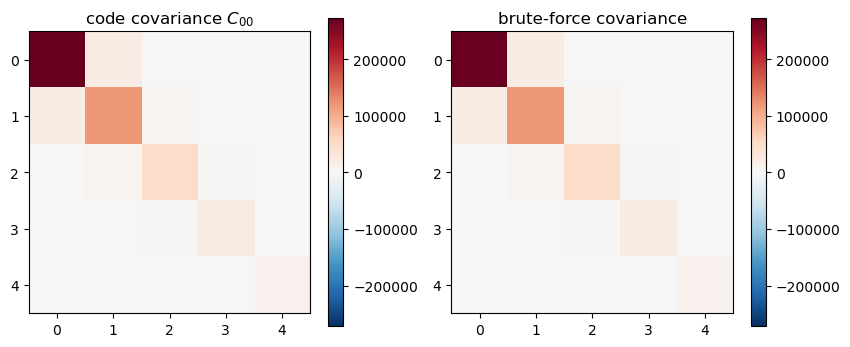

In [8]:
Cb = bruteforce_monopole(R, k_edges, lambda kk: np.interp(kk, k, P0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = np.max(np.abs(C))
im0 = axes[0].imshow(C, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('code covariance $C_{00}$')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(Cb, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('brute-force covariance')
plt.colorbar(im1, ax=axes[1])
plt.show()

### Step 4: check the diagonal and first off-diagonal agreement

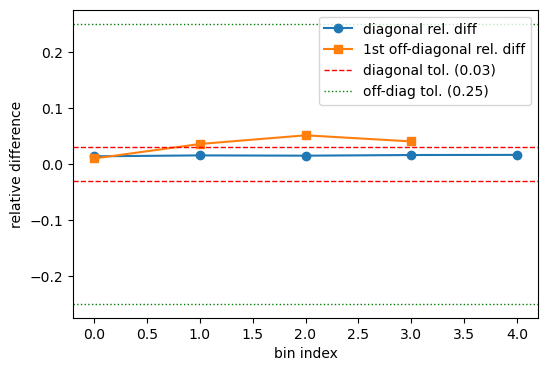

diagonal rel. diff: [0.01322938 0.01486807 0.01436928 0.01553771 0.01577538]
off-diagonal rel. diff: [0.00932617 0.03524087 0.05072962 0.03985718]


In [9]:
d = np.diag(C) / np.diag(Cb) - 1
o = np.diag(C, 1) / np.diag(Cb, 1) - 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(d, 'o-', label='diagonal rel. diff')
ax.plot(o, 's-', label='1st off-diagonal rel. diff')
ax.axhline(0.03, color='r', ls='--', lw=1, label='diagonal tol. (0.03)')
ax.axhline(-0.03, color='r', ls='--', lw=1)
ax.axhline(0.25, color='g', ls=':', lw=1, label='off-diag tol. (0.25)')
ax.axhline(-0.25, color='g', ls=':', lw=1)
ax.set_xlabel('bin index')
ax.set_ylabel('relative difference')
ax.legend()
plt.show()

print('diagonal rel. diff:', d)
print('off-diagonal rel. diff:', o)

## Test 3 — far-away sphere: multipole ratios approach the periodic-box values

### Step 1: place the sphere far from the observer and build the Kaiser multipoles

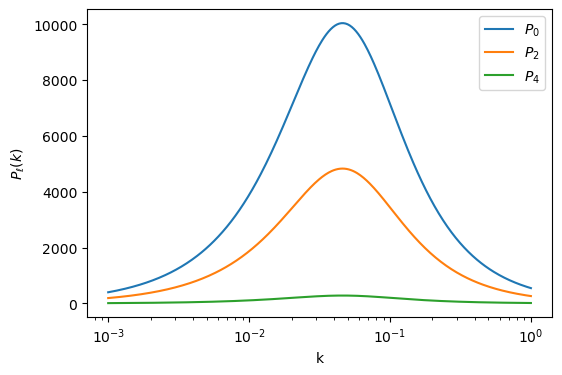

In [10]:
R, n, nbar = 500.0, 12000, 2e-4
rnd, alpha = sphere_randoms(R, n, center=(0, 0, 40000.0), nbar=nbar)
tr = Tracer('T', rnd, alpha)
k, P0 = pk_model()
f, b = 0.8, 2.0
beta = f / b
# Kaiser multipoles
P2 = P0 * (4 * beta / 3 + 4 * beta ** 2 / 7) / (1 + 2 * beta / 3 + beta ** 2 / 5)
P4 = P0 * (8 * beta ** 2 / 35) / (1 + 2 * beta / 3 + beta ** 2 / 5)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(k, P0, label='$P_0$')
ax.semilogx(k, P2, label='$P_2$')
ax.semilogx(k, P4, label='$P_4$')
ax.set_xlabel('k')
ax.set_ylabel('$P_\\ell(k)$')
ax.legend()
plt.show()

### Step 2: compute the covariance for `ells=(0,2,4)`

In [11]:
model = PowerSpectrumModel()
model.add(('T', 'T'), {0: (k, P0), 2: (k, P2), 4: (k, P4)})
k_edges = np.array([0.06, 0.08, 0.10])
cov = GaussianCovariance([tr], k_edges, ells=(0, 2, 4), L_max=4, s_max=2 * R, ds=2.0, ds_pair=10.0,
                         shot_noise=False, n_sub=2500)
cov.compute_windows([('T', 'T')]).set_model(model)
kc = 0.5 * (k_edges[:-1] + k_edges[1:])
PL = {0: np.interp(kc, k, P0), 2: np.interp(kc, k, P2), 4: np.interp(kc, k, P4)}
C = {(l1, l2): cov.block(('T', 'T'), ('T', 'T'), l1, l2) for l1 in (0, 2, 4) for l2 in (0, 2, 4)}
print('computed blocks:', list(C.keys()))

computed blocks: [(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4)]


### Step 3: compare code ratios `C_{l1 l2}/C_00` to the periodic-box expectation, and check exchange symmetry

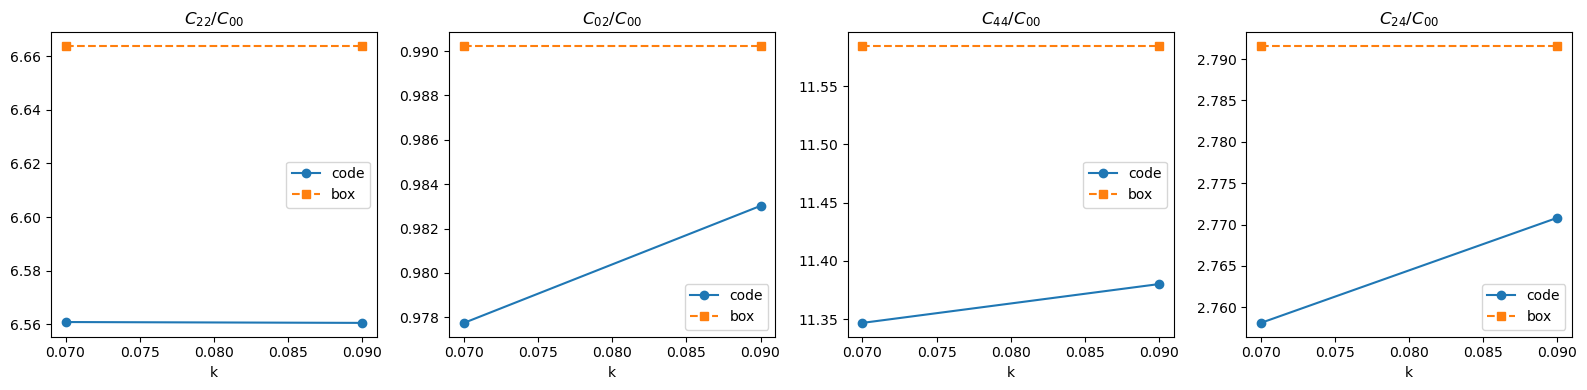

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
pairs = [(2, 2), (0, 2), (4, 4), (2, 4)]
for ax, (l1, l2) in zip(axes, pairs):
    box = (2 * l1 + 1) * (2 * l2 + 1) * sum(PL[L1] * PL[L2] * _legendre4(l1, l2, L1, L2)
                                            for L1 in (0, 2, 4) for L2 in (0, 2, 4))
    box00 = sum(PL[L1] * PL[L2] * _legendre4(0, 0, L1, L2) for L1 in (0, 2, 4) for L2 in (0, 2, 4))
    ratio_code = np.diag(C[(l1, l2)]) / np.diag(C[(0, 0)])
    ratio_box = box / box00
    ax.plot(kc, ratio_code, 'o-', label='code')
    ax.plot(kc, ratio_box, 's--', label='box')
    ax.set_title(f'$C_{{{l1}{l2}}}/C_{{00}}$')
    ax.set_xlabel('k')
    ax.legend()
plt.tight_layout()
plt.show()

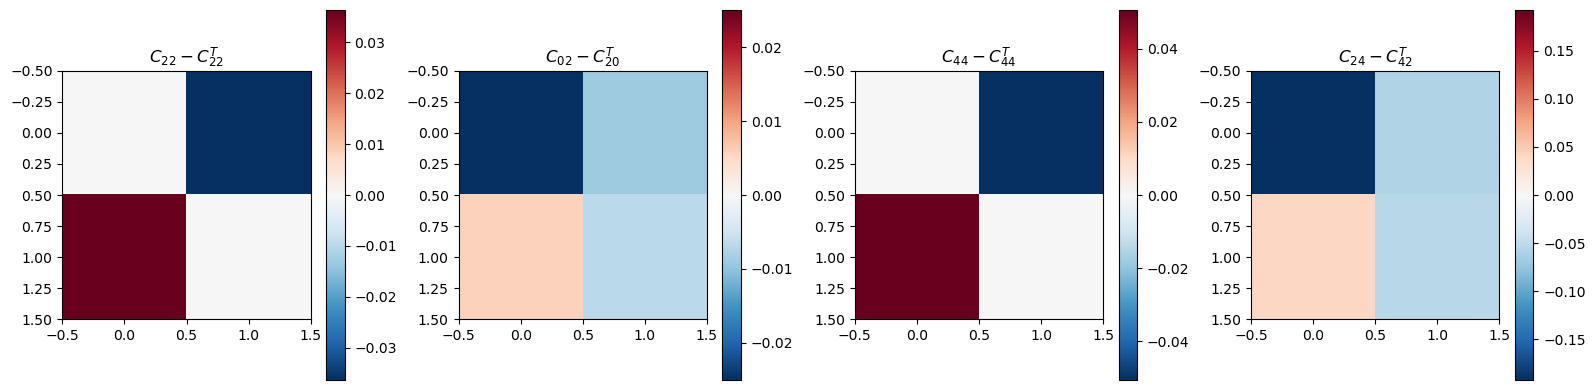

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (l1, l2) in zip(axes, pairs):
    asym = C[(l1, l2)] - C[(l2, l1)].T
    vmax = max(1e-12, np.max(np.abs(asym)))
    im = ax.imshow(asym, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'$C_{{{l1}{l2}}} - C_{{{l2}{l1}}}^T$')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Cubic box test (periodic-box limit)

Based on the "Box test" in `thecov2.ipynb`: place a small cubic random catalogue far from the observer (plane-parallel limit) with a *flat* monopole `P0` plus shot noise, and compare the code's diagonal covariance against the standard periodic-box Gaussian formula

$$C_{00}(k,k) = \frac{2\left(P_0 + 1/\bar n\right)^2}{N_\text{modes}(k)}, \qquad N_\text{modes}(k) = \frac{V}{6\pi^2}\left(k_\text{hi}^3 - k_\text{lo}^3\right).$$

Note the box here is a genuine finite (non-periodic) point set, so this is only an approximate cross-check (unlike the periodic-box FFT used by `thecov2.ipynb`); the parameters below are tuned to the shot-noise-dominated regime where the two agree well.

In [14]:
def box_randoms(L, n, center=(0.0, 0.0, 0.0), nbar=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    pos = rng.uniform(-L / 2, L / 2, size=(n, 3)) + np.asarray(center)
    V = L ** 3
    alpha = nbar * V / n
    return {'POSITION': pos, 'WEIGHT': np.ones(n), 'NZ': np.full(n, nbar)}, alpha


# box side, distance from the observer (plane-parallel limit), catalogue size, number density, flat P0
L = 1400.0
R0 = 6000.0
n = 3_000_000
nbar = 1e-4
P0_flat = 100.0
k_edges = np.arange(0.0, 0.16, 0.02)

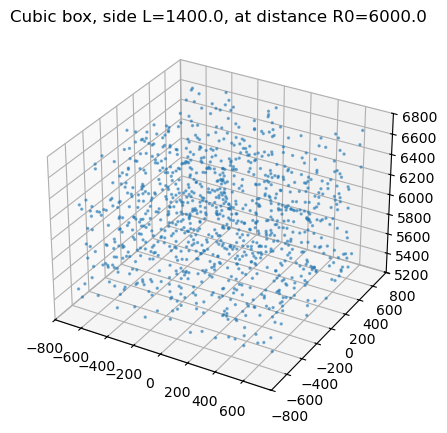

In [ ]:
rnd, alpha = box_randoms(L, n, center=(0, 0, R0), nbar=nbar)
tr = Tracer('T', rnd, alpha)
k = np.linspace(1e-6, 0.5, 50)
model = PowerSpectrumModel()
# model.add(('T', 'T'), {0: (k, np.full_like(k, P0_flat))})
model.add(('T', 'T'), {0: (k, P0), 2: (k, P2), 4: (k, P4)})


fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': '3d'})
sub = rnd['POSITION'][::3000]
ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=2, alpha=0.5)
ax.set_title(f'Cubic box, side L={L}, at distance R0={R0}')
plt.show()

In [16]:
s_max = tr.s_max()
cov = GaussianCovariance([tr], k_edges, ells=(0,), L_max=0, s_max=s_max, ds=4.0, ds_pair=20.0,
                         shot_noise=True, n_sub=2000)
cov.compute_windows([('T', 'T')]).set_model(model)
C = cov.block(('T', 'T'), ('T', 'T'), 0, 0)
C

array([[ 5.17788170e+05,  1.58515189e+04,  5.73726516e+02,
        -1.04448268e+02, -1.61112810e+02, -8.06717457e+01,
         7.48698877e+02],
       [ 1.58515189e+04,  7.87091958e+04,  3.49827014e+03,
         3.39719198e+01, -1.31019102e+02,  2.49720920e+02,
         9.42803502e+01],
       [ 5.73726516e+02,  3.49827014e+03,  2.90524385e+04,
         1.41936343e+03,  2.35104216e+02,  3.02018053e+01,
         4.09482188e+01],
       [-1.04448268e+02,  3.39719198e+01,  1.41936343e+03,
         1.51433200e+04,  8.73349551e+02,  6.35958872e+01,
         4.46227989e+01],
       [-1.61112810e+02, -1.31019102e+02,  2.35104216e+02,
         8.73349551e+02,  9.12052441e+03,  5.79171586e+02,
         5.79031523e+01],
       [-8.06717457e+01,  2.49720920e+02,  3.02018053e+01,
         6.35958872e+01,  5.79171586e+02,  6.13129082e+03,
         3.99434601e+02],
       [ 7.48698877e+02,  9.42803502e+01,  4.09482188e+01,
         4.46227989e+01,  5.79031523e+01,  3.99434601e+02,
         4.3955930

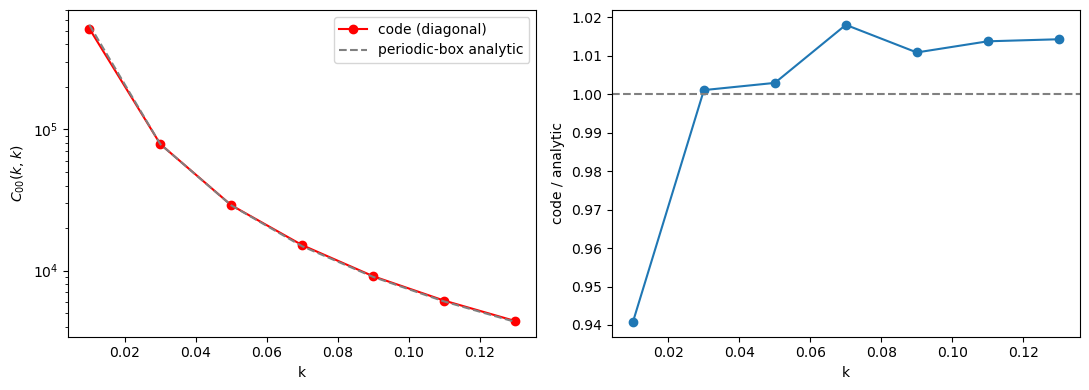

In [17]:
Nmodes = L ** 3 / (6 * np.pi ** 2) * (k_edges[1:] ** 3 - k_edges[:-1] ** 3)
analytic = 2 * (P0_flat + 1 / nbar) ** 2 / Nmodes
kc = 0.5 * (k_edges[:-1] + k_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(kc, np.diag(C), 'o-', c='red', label='code (diagonal)')
axes[0].semilogy(kc, analytic, '--', c='gray', label='periodic-box analytic')
axes[0].set_xlabel('k')
axes[0].set_ylabel('$C_{00}(k,k)$')
axes[0].legend()

axes[1].plot(kc, np.diag(C) / analytic, 'o-')
axes[1].axhline(1.0, color='gray', ls='--')
axes[1].set_xlabel('k')
axes[1].set_ylabel('code / analytic')
plt.tight_layout()
plt.show()